# Лабораторная работа 3. Модификации градиентного спуска

## Цель работы

Реализовать шесть модификаций градиентного спуска - **Momentum, Nesterov, AdaGrad, RMSProp, AdaDelta, Adam** - и сравнить их на квадратичных функциях (хорошо и плохо обусловленной) и на сложных функциях Розенброка, Экли и Химмельблау. На квадратичных смотрим, как параметры методов влияют на число итераций (таблицы, line-графики и heatmap), на сложных - чувствительность к параметрам и траектории. Везде точность `ε = 1e-8` (критерий `‖∇f‖ ≤ ε`), для перебора параметров - одна стартовая точка на функцию.

## Описание методов

Все методы имеют вид $x_{k+1} = x_k - \alpha\, p_k$, где $g = \nabla f$ - точный градиент, а вектор $p_k$ строится по внутренним переменным. Операции с векторами (квадрат, корень, деление) - покоординатные.

- **Momentum**: $\;m \leftarrow \beta m + g,\quad x \leftarrow x - \alpha m.\;$ Инерция накапливает движение вдоль устойчивого направления.
- **Nesterov**: $\;y = x + \beta (x - x_{\text{prev}}),\quad x \leftarrow y - \alpha \nabla f(y).\;$ Градиент считается в "предсказанной" точке.
- **AdaGrad**: $\;G \leftarrow G + g^2,\quad x \leftarrow x - \alpha\, \dfrac{g}{\sqrt{G} + \varepsilon}.\;$ Шаг по "активным" координатам падает; со временем затухает.
- **RMSProp**: $\;G \leftarrow \rho G + (1-\rho) g^2,\quad x \leftarrow x - \alpha\, \dfrac{g}{\sqrt{G} + \varepsilon}.\;$ Экспоненциальное забывание вместо накопления.
- **AdaDelta**: $\;G \leftarrow \rho G + (1-\rho) g^2,\quad \Delta x = -\dfrac{\sqrt{u + \varepsilon}}{\sqrt{G + \varepsilon}}\, g,\quad u \leftarrow \rho u + (1-\rho)\Delta x^2,\quad x \leftarrow x + \Delta x.\;$ Явного шага $\alpha$ нет.
- **Adam**: $\;m \leftarrow \beta_1 m + (1-\beta_1) g,\quad v \leftarrow \beta_2 v + (1-\beta_2) g^2,\quad \hat m = \dfrac{m}{1-\beta_1^{t}},\quad \hat v = \dfrac{v}{1-\beta_2^{t}},\quad x \leftarrow x - \alpha\, \dfrac{\hat m}{\sqrt{\hat v} + \varepsilon}.\;$ Momentum + RMSProp с поправкой на смещение.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## Тестовые функции и их градиенты

In [ ]:
"""Тестовые модели и их градиенты

Каждая функция принимает точку p = [x, y]
Градиент принимает p и возвращает numpy-массив [df/dx, df/dy]
"""

import numpy as np

def f_quad_good(p):
    x, y = p
    return x ** 2 + 2 * y ** 2

def grad_quad_good(p):
    x, y = p
    return np.array([2 * x, 4 * y])

def g_quad_bad(p):
    x, y = p
    return x ** 2 + 100 * y ** 2

def grad_quad_bad(p):
    x, y = p
    return np.array([2 * x, 200 * y])

def rosenbrock(p):
    x, y = p
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

def grad_rosenbrock(p):
    x, y = p
    dx = -2 * (1 - x) - 400 * x * (y - x ** 2)
    dy = 200 * (y - x ** 2)
    return np.array([dx, dy])

def ackley(p):
    x, y = p
    r = np.sqrt(0.5 * (x ** 2 + y ** 2))
    s = 0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))
    return -20 * np.exp(-0.2 * r) - np.exp(s) + 20 + np.e

def grad_ackley(p):
    x, y = p
    r = np.sqrt(0.5 * (x ** 2 + y ** 2))
    s = 0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))
    if r == 0:
        first_x = first_y = 0.0
    else:
        first_x = 2 * x * np.exp(-0.2 * r) / r
        first_y = 2 * y * np.exp(-0.2 * r) / r
    dx = first_x + np.pi * np.sin(2 * np.pi * x) * np.exp(s)
    dy = first_y + np.pi * np.sin(2 * np.pi * y) * np.exp(s)
    return np.array([dx, dy])

def himmelblau(p):
    x, y = p
    return (x ** 2 + y - 11) ** 2 + (x + y ** 2 - 7) ** 2

def grad_himmelblau(p):
    x, y = p
    a = x ** 2 + y - 11
    b = x + y ** 2 - 7
    dx = 4 * x * a + 2 * b
    dy = 2 * a + 4 * y * b
    return np.array([dx, dy])


## Реализация методов

In [ ]:
"""Модификации градиентного спуска из лекции 7

Все методы первого порядка: используют только градиент (функцию не вычисляют),
поэтому считаем число итераций. Все операции с векторами (квадрат, корень,
деление) - покоординатные

Критерий остановки один: ||grad f(x)|| <= tol. Плюс ограничение по числу
итераций и проверка на расходимость (точка ушла слишком далеко)

Обозначения: tol - точность остановки по градиенту (ε из условия, 1e-8),
eps - маленький регуляризатор в знаменателе адаптивных методов
"""

import numpy as np

def _result(x, traj, iters, converged):
    return {"x": x, "traj": np.array(traj), "iters": iters, "converged": converged}

def momentum(grad, x0, alpha=0.01, beta=0.9, tol=1e-8, max_iter=100000):
    x = np.array(x0, dtype=float)
    m = np.zeros_like(x)
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            converged = True
            break
        m = beta * m + g
        x = x - alpha * m
        if np.linalg.norm(x) > 1e6:
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged)

def nesterov(grad, x0, alpha=0.01, beta=0.9, tol=1e-8, max_iter=100000):
    x = np.array(x0, dtype=float)
    x_prev = x.copy()
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        if np.linalg.norm(grad(x)) <= tol:
            converged = True
            break
        y = x + beta * (x - x_prev)
        g = grad(y)
        x_prev = x
        x = y - alpha * g
        if np.linalg.norm(x) > 1e6:
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged)

def adagrad(grad, x0, alpha=1.0, eps=1e-8, tol=1e-8, max_iter=100000):
    x = np.array(x0, dtype=float)
    G = np.zeros_like(x)
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            converged = True
            break
        G = G + g * g
        x = x - alpha * g / (np.sqrt(G) + eps)
        if np.linalg.norm(x) > 1e6:
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged)

def rmsprop(grad, x0, alpha=0.01, rho=0.9, eps=1e-8, tol=1e-8, max_iter=100000):
    x = np.array(x0, dtype=float)
    G = np.zeros_like(x)
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            converged = True
            break
        G = rho * G + (1 - rho) * g * g
        x = x - alpha * g / (np.sqrt(G) + eps)
        if np.linalg.norm(x) > 1e6:
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged)

def adadelta(grad, x0, rho=0.95, eps=1e-6, tol=1e-8, max_iter=100000):
    x = np.array(x0, dtype=float)
    G = np.zeros_like(x)
    u = np.zeros_like(x)
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            converged = True
            break
        G = rho * G + (1 - rho) * g * g
        dx = -np.sqrt(u + eps) / np.sqrt(G + eps) * g
        u = rho * u + (1 - rho) * dx * dx
        x = x + dx
        if np.linalg.norm(x) > 1e6:
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged)

def adam(grad, x0, alpha=0.05, beta1=0.9, beta2=0.999, eps=1e-8, tol=1e-8, max_iter=100000):
    x = np.array(x0, dtype=float)
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            converged = True
            break
        t = it + 1
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g * g
        mhat = m / (1 - beta1 ** t)
        vhat = v / (1 - beta2 ** t)
        x = x - alpha * mhat / (np.sqrt(vhat) + eps)
        if np.linalg.norm(x) > 1e6:
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged)

## Вспомогательные функции

In [ ]:
TOL = 1e-8
MAXIT = 50000
METHODS = {"Momentum": momentum, "Nesterov": nesterov, "AdaGrad": adagrad,
           "RMSProp": rmsprop, "AdaDelta": adadelta, "Adam": adam}

def run(name, grad, x0, **params):
    return METHODS[name](grad, x0, tol=TOL, max_iter=MAXIT, **params)

def itval(res):
    return res["iters"] if res["converged"] else None

def fnum(v, d=4):
    return f"{v:.{d}g}"

def print_table(title, headers, rows):
    print("\n" + title)
    cols = list(zip(*([headers] + rows)))
    widths = [max(len(str(c)) for c in col) for col in cols]
    def fmt(r):
        return " | ".join(str(c).ljust(widths[i]) for i, c in enumerate(r))
    print(fmt(headers))
    print("-+-".join("-" * w for w in widths))
    for r in rows:
        print(fmt(r))

def line_plot(title, xlabel, xvals, iters):
    xs = [x for x, v in zip(xvals, iters) if v is not None]
    ys = [v for v in iters if v is not None]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(xs, ys, "-o")
    ax.set_xlabel(xlabel); ax.set_ylabel("число итераций"); ax.set_title(title)
    ax.set_yscale("log"); ax.grid(True, which="both", linewidth=0.3)
    plt.show()

def heatmap(title, rowlabel, rowvals, collabel, colvals, M):
    A = np.array([[np.nan if v is None else float(v) for v in row] for row in M])
    L = np.log10(A); masked = np.ma.masked_invalid(L)
    finite = L[np.isfinite(L)]
    mid = 0.5 * (finite.min() + finite.max()) if finite.size else 0
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.cm.viridis_r.copy(); cmap.set_bad("lightgray")
    im = ax.imshow(masked, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(colvals))); ax.set_xticklabels(colvals)
    ax.set_yticks(range(len(rowvals))); ax.set_yticklabels(rowvals)
    ax.set_xlabel(collabel); ax.set_ylabel(rowlabel); ax.set_title(title)
    for i in range(len(rowvals)):
        for j in range(len(colvals)):
            v = M[i][j]
            if v is None:
                txt, col = "-", "black"
            else:
                txt, col = str(v), ("white" if np.log10(v) > mid else "black")
            ax.text(j, i, txt, ha="center", va="center", color=col, fontsize=8)
    cb = fig.colorbar(im); cb.set_label("log10(итераций), '-' = не сошелся")
    plt.show()

PLOT_CFG = {
    "f": ((-6, 6), (-6, 6), np.linspace(2, 80, 12), [(0, 0)]),
    "g": ((-6, 6), (-6, 6), np.logspace(0, 3.4, 14), [(0, 0)]),
    "rosen": ((-2, 2), (-1, 3), np.logspace(0, 3.5, 18), [(1, 1)]),
    "ackley": ((-5, 5), (-5, 5), np.linspace(0.5, 14, 14), [(0, 0)]),
    "himmel": ((-5, 5), (-5, 5), np.logspace(0, 2.8, 18),
               [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]),
}

def _subsample(traj, maxpts=1500):
    if len(traj) > maxpts:
        idx = np.linspace(0, len(traj) - 1, maxpts).astype(int)
        return traj[idx]
    return traj

def traj_figure(title, f, key, runs):
    xlim, ylim, levels, minpts = PLOT_CFG[key]
    xs = np.linspace(xlim[0], xlim[1], 350); ys = np.linspace(ylim[0], ylim[1], 350)
    X, Y = np.meshgrid(xs, ys); Z = f((X, Y))
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for ax, (label, traj) in zip(axes.ravel(), runs):
        ax.contour(X, Y, Z, levels=levels, cmap="Greys", linewidths=0.5)
        t = _subsample(traj)
        ax.plot(t[:, 0], t[:, 1], "-", color="tab:blue", linewidth=1.0)
        ax.plot(t[0, 0], t[0, 1], "go", markersize=5)
        ax.plot([p[0] for p in minpts], [p[1] for p in minpts], "r*", markersize=10)
        ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_title(label, fontsize=10)
    fig.suptitle(title); fig.tight_layout(); plt.show()

GRIDS = {
    "alpha_mn_f": [0.05, 0.1, 0.15, 0.2, 0.3],
    "alpha_mn_g": [0.002, 0.004, 0.006, 0.008, 0.009],
    "beta_mn": [0.0, 0.5, 0.7, 0.9, 0.95],
    "alpha_ada": [0.1, 0.3, 0.5, 1.0, 2.0],
    "alpha_rms": [0.01, 0.03, 0.05, 0.1, 0.3],
    "rho_rms": [0.5, 0.9, 0.95, 0.99, 0.999],
    "rho_delta": [0.5, 0.9, 0.95, 0.99, 0.999],
    "b1_adam": [0.5, 0.7, 0.9, 0.95, 0.99],
    "b2_adam": [0.9, 0.95, 0.99, 0.999, 0.9999],
}
CHOSEN = {
    "f": {"Momentum": dict(alpha=0.2, beta=0.5), "Nesterov": dict(alpha=0.2, beta=0.5),
          "AdaGrad": dict(alpha=1.0), "RMSProp": dict(alpha=0.1, rho=0.9),
          "AdaDelta": dict(rho=0.9, eps=1e-4), "Adam": dict(alpha=0.1, beta1=0.9, beta2=0.999)},
    "g": {"Momentum": dict(alpha=0.008, beta=0.7), "Nesterov": dict(alpha=0.006, beta=0.9),
          "AdaGrad": dict(alpha=1.0), "RMSProp": dict(alpha=0.05, rho=0.9),
          "AdaDelta": dict(rho=0.9, eps=1e-4), "Adam": dict(alpha=0.1, beta1=0.9, beta2=0.999)},
}
COMPLEX_SETS = {
    "Momentum": [("α=0.001,β=0.9", dict(alpha=0.001, beta=0.9)),
                 ("α=0.0005,β=0.9", dict(alpha=0.0005, beta=0.9)),
                 ("α=0.001,β=0.5", dict(alpha=0.001, beta=0.5))],
    "Nesterov": [("α=0.001,β=0.9", dict(alpha=0.001, beta=0.9)),
                 ("α=0.0005,β=0.9", dict(alpha=0.0005, beta=0.9)),
                 ("α=0.001,β=0.5", dict(alpha=0.001, beta=0.5))],
    "AdaGrad": [("α=0.1", dict(alpha=0.1)), ("α=0.5", dict(alpha=0.5)), ("α=1.0", dict(alpha=1.0))],
    "RMSProp": [("α=0.001,ρ=0.9", dict(alpha=0.001, rho=0.9)),
                ("α=0.01,ρ=0.9", dict(alpha=0.01, rho=0.9)),
                ("α=0.01,ρ=0.99", dict(alpha=0.01, rho=0.99))],
    "AdaDelta": [("ρ=0.9", dict(rho=0.9, eps=1e-4)), ("ρ=0.95", dict(rho=0.95, eps=1e-4)),
                 ("ρ=0.99", dict(rho=0.99, eps=1e-4))],
    "Adam": [("α=0.01", dict(alpha=0.01)), ("α=0.05", dict(alpha=0.05)), ("α=0.1", dict(alpha=0.1))],
}
COMPLEX_CHOSEN = {
    "Momentum": dict(alpha=0.001, beta=0.9), "Nesterov": dict(alpha=0.001, beta=0.9),
    "AdaGrad": dict(alpha=0.5), "RMSProp": dict(alpha=0.01, rho=0.9),
    "AdaDelta": dict(rho=0.95, eps=1e-4), "Adam": dict(alpha=0.05, beta1=0.9, beta2=0.999),
}
STARTS = {
    "rosen": [(-1.2, 1.0), (1.5, 2.0)],
    "ackley": [(2.0, 2.0), (-2.0, 3.0)],
    "himmel": [(0.0, 0.0), (-3.0, -3.0)],
}

def study_quadratic(key, name, grad, x0):
    a_mn = GRIDS["alpha_mn_f"] if key == "f" else GRIDS["alpha_mn_g"]
    b_mn = GRIDS["beta_mn"]
    for mname in ["Momentum", "Nesterov"]:
        M = [[itval(run(mname, grad, x0, alpha=a, beta=b)) for b in b_mn] for a in a_mn]
        rows = [[fnum(a)] + [("-" if v is None else v) for v in M[i]] for i, a in enumerate(a_mn)]
        print_table(f"{mname} на {name}: число итераций (строки α, столбцы β)",
                    ["α \\ β"] + [str(b) for b in b_mn], rows)
        heatmap(f"{mname}, {name}", "α", a_mn, "β", b_mn, M)
    a_ada = GRIDS["alpha_ada"]
    it = [itval(run("AdaGrad", grad, x0, alpha=a)) for a in a_ada]
    print_table(f"AdaGrad на {name}: итерации от начального шага α",
                ["α"] + [fnum(a) for a in a_ada], [["итераций"] + [("-" if v is None else v) for v in it]])
    line_plot(f"AdaGrad, {name}", "начальный шаг α", a_ada, it)
    a_rms = GRIDS["alpha_rms"]; r_rms = GRIDS["rho_rms"]
    M = [[itval(run("RMSProp", grad, x0, alpha=a, rho=r)) for r in r_rms] for a in a_rms]
    rows = [[fnum(a)] + [("-" if v is None else v) for v in M[i]] for i, a in enumerate(a_rms)]
    print_table(f"RMSProp на {name}: число итераций (строки α, столбцы ρ)",
                ["α \\ ρ"] + [str(r) for r in r_rms], rows)
    heatmap(f"RMSProp, {name}", "α", a_rms, "ρ", r_rms, M)
    r_d = GRIDS["rho_delta"]
    it = [itval(run("AdaDelta", grad, x0, rho=r, eps=1e-4)) for r in r_d]
    print_table(f"AdaDelta на {name}: итерации от ρ (eps=1e-4)",
                ["ρ"] + [str(r) for r in r_d], [["итераций"] + [("-" if v is None else v) for v in it]])
    line_plot(f"AdaDelta, {name}", "ρ", r_d, it)
    b1 = GRIDS["b1_adam"]; b2 = GRIDS["b2_adam"]
    M = [[itval(run("Adam", grad, x0, alpha=0.1, beta1=x, beta2=y)) for y in b2] for x in b1]
    rows = [[str(x)] + [("-" if v is None else v) for v in M[i]] for i, x in enumerate(b1)]
    print_table(f"Adam на {name}: число итераций (строки β1, столбцы β2), α=0.1",
                ["β1 \\ β2"] + [str(y) for y in b2], rows)
    heatmap(f"Adam, {name} (α=0.1)", "β1", b1, "β2", b2, M)

## Пункт 1

Влияние параметров методов на квадратичных функциях. Для каждого метода перебираем его параметры (≥5 значений): один параметр - line-график (AdaGrad, AdaDelta), два - heatmap (Momentum, Nesterov, RMSProp, Adam). В клетках heatmap - число итераций до `‖∇f‖≤1e-8`; "-" = метод не сошелся.


Momentum на f (k=2): число итераций (строки α, столбцы β)
α \ β | 0.0 | 0.5 | 0.7 | 0.9 | 0.95
------+-----+-----+-----+-----+-----
0.05  | 197 | 61  | 113 | 385 | 788 
0.1   | 93  | 62  | 113 | 393 | 754 
0.15  | 59  | 59  | 116 | 379 | 785 
0.2   | 41  | 58  | 117 | 374 | 797 
0.3   | 23  | 61  | 115 | 396 | 773 


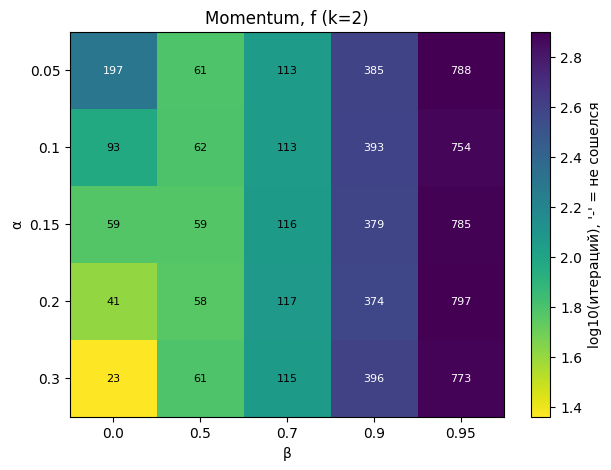


Nesterov на f (k=2): число итераций (строки α, столбцы β)
α \ β | 0.0 | 0.5 | 0.7 | 0.9 | 0.95
------+-----+-----+-----+-----+-----
0.05  | 197 | 75  | 88  | 183 | 201 
0.1   | 93  | 45  | 63  | 119 | 139 
0.15  | 59  | 37  | 54  | 79  | 95  
0.2   | 41  | 34  | 45  | 53  | 62  
0.3   | 23  | 31  | 39  | 50  | 53  


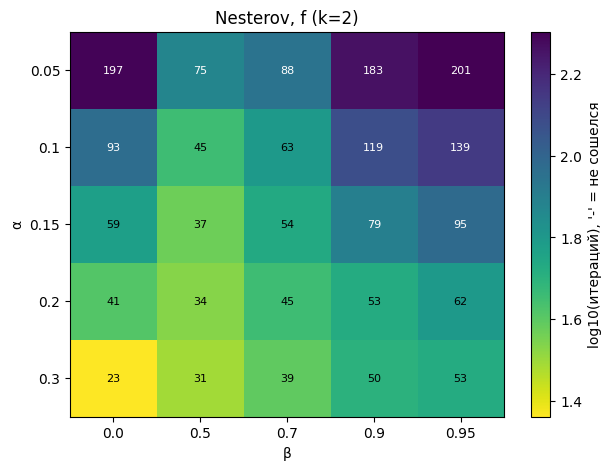


AdaGrad на f (k=2): итерации от начального шага α
α        | 0.1   | 0.3  | 0.5 | 1   | 2 
---------+-------+------+-----+-----+---
итераций | 13890 | 1695 | 660 | 192 | 58


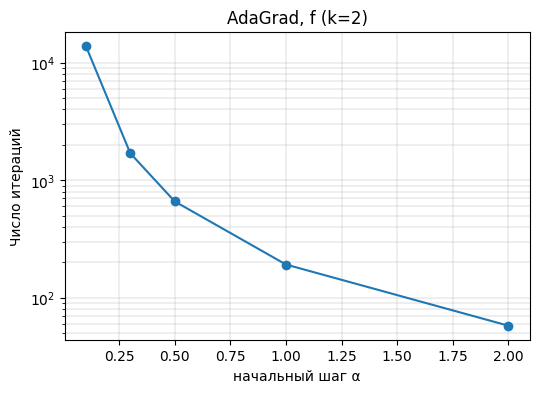


RMSProp на f (k=2): число итераций (строки α, столбцы ρ)
α \ ρ | 0.5 | 0.9 | 0.95 | 0.99 | 0.999
------+-----+-----+------+------+------
0.01  | -   | 566 | 628  | 985  | 1145 
0.03  | -   | 223 | 273  | 462  | 200  
0.05  | -   | 152 | 195  | 293  | 85   
0.1   | -   | 95  | 124  | 133  | 24   
0.3   | -   | 45  | 51   | 25   | 23   


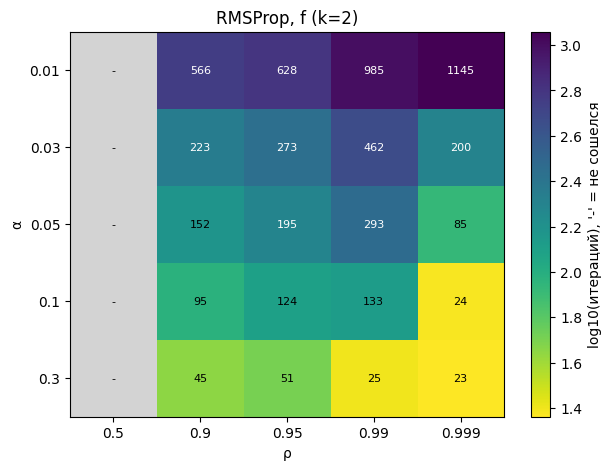


AdaDelta на f (k=2): итерации от ρ (eps=1e-4)
ρ        | 0.5 | 0.9 | 0.95 | 0.99 | 0.999
---------+-----+-----+------+------+------
итераций | -   | 268 | 334  | 612  | 287  


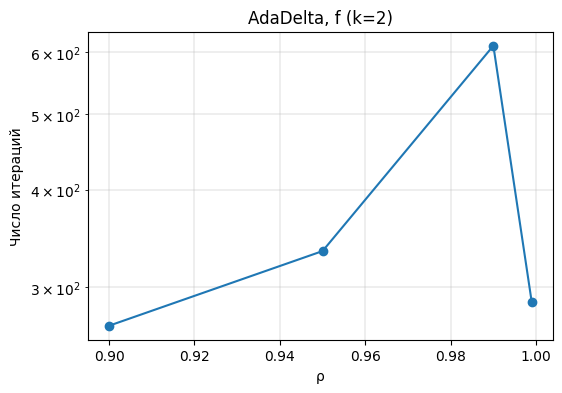


Adam на f (k=2): число итераций (строки β1, столбцы β2), α=0.1
β1 \ β2 | 0.9 | 0.95 | 0.99 | 0.999 | 0.9999
--------+-----+------+------+-------+-------
0.5     | 121 | 144  | 258  | 337   | 347   
0.7     | -   | 171  | 208  | 303   | 313   
0.9     | -   | -    | 375  | 358   | 328   
0.95    | -   | -    | 755  | 726   | 674   
0.99    | -   | -    | -    | 3102  | 2963  


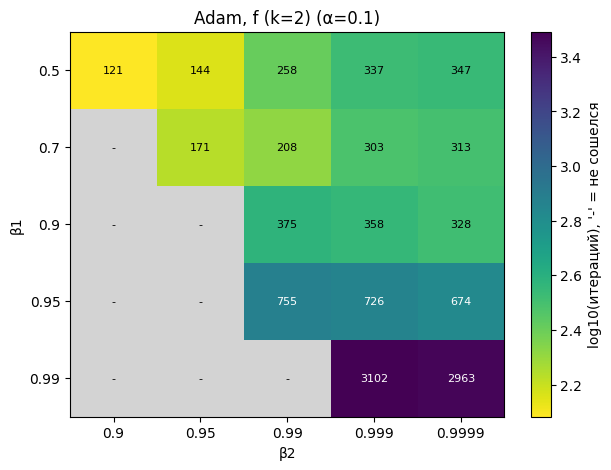

In [5]:
study_quadratic("f", "f (k=2)", grad_quad_good, (5., 5.))


Momentum на g (k=100): число итераций (строки α, столбцы β)
α \ β | 0.0  | 0.5  | 0.7  | 0.9 | 0.95
------+------+------+------+-----+-----
0.002 | 5171 | 2560 | 1496 | 431 | 865 
0.004 | 2581 | 1265 | 716  | 430 | 867 
0.006 | 1717 | 833  | 454  | 438 | 912 
0.008 | 1285 | 617  | 321  | 439 | 839 
0.009 | 1141 | 544  | 275  | 431 | 886 


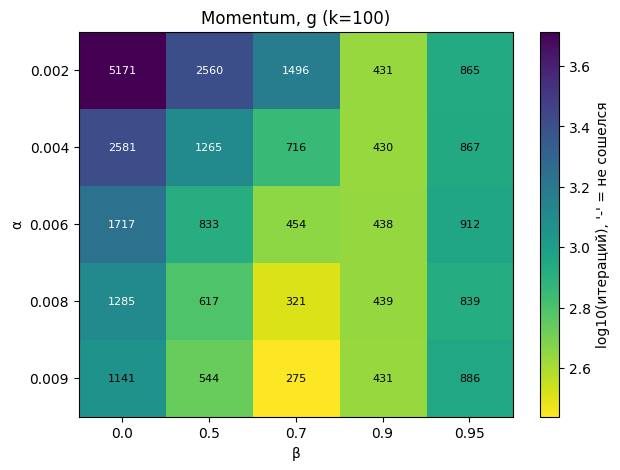


Nesterov на g (k=100): число итераций (строки α, столбцы β)
α \ β | 0.0  | 0.5  | 0.7  | 0.9 | 0.95
------+------+------+------+-----+-----
0.002 | 5171 | 2571 | 1511 | 340 | 631 
0.004 | 2581 | 1276 | 733  | 333 | 571 
0.006 | 1717 | 844  | 471  | 314 | 547 
0.008 | 1285 | -    | -    | -   | -   
0.009 | 1141 | -    | -    | -   | -   


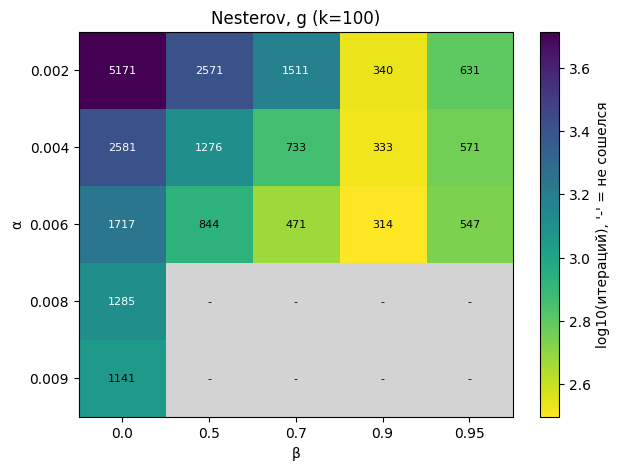


AdaGrad на g (k=100): итерации от начального шага α
α        | 0.1   | 0.3  | 0.5 | 1   | 2 
---------+-------+------+-----+-----+---
итераций | 16398 | 2000 | 778 | 226 | 68


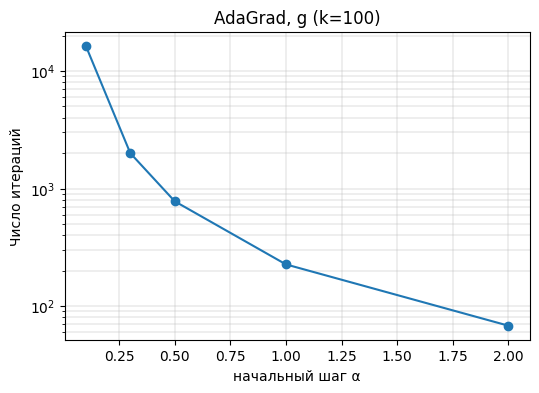


RMSProp на g (k=100): число итераций (строки α, столбцы ρ)
α \ ρ | 0.5 | 0.9 | 0.95 | 0.99 | 0.999
------+-----+-----+------+------+------
0.01  | -   | 569 | 634  | 1017 | 1296 
0.03  | -   | 226 | 279  | 491  | 233  
0.05  | -   | 154 | 200  | 318  | 99   
0.1   | -   | 97  | 130  | 149  | 29   
0.3   | -   | 46  | 55   | 29   | 27   


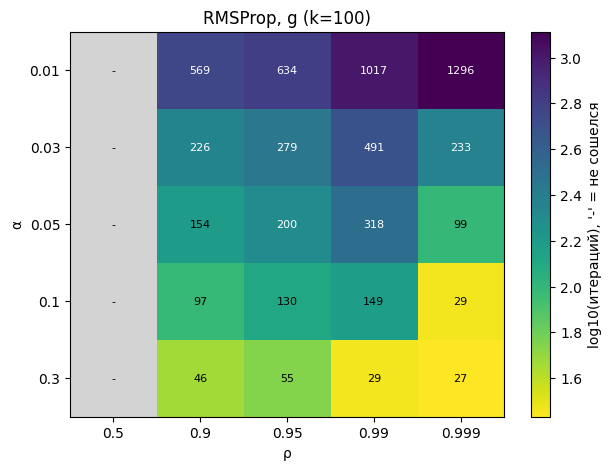


AdaDelta на g (k=100): итерации от ρ (eps=1e-4)
ρ        | 0.5 | 0.9 | 0.95 | 0.99 | 0.999
---------+-----+-----+------+------+------
итераций | -   | 271 | 340  | 653  | 337  


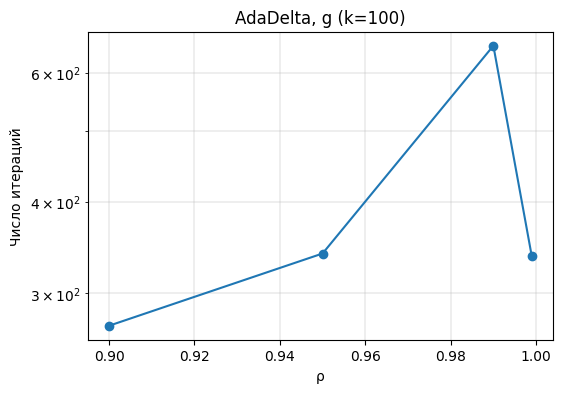


Adam на g (k=100): число итераций (строки β1, столбцы β2), α=0.1
β1 \ β2 | 0.9 | 0.95 | 0.99 | 0.999 | 0.9999
--------+-----+------+------+-------+-------
0.5     | 133 | 151  | 275  | 373   | 386   
0.7     | -   | 186  | 237  | 330   | 344   
0.9     | -   | -    | 460  | 358   | 441   
0.95    | -   | -    | 903  | 869   | 835   
0.99    | -   | -    | -    | 4341  | 3884  


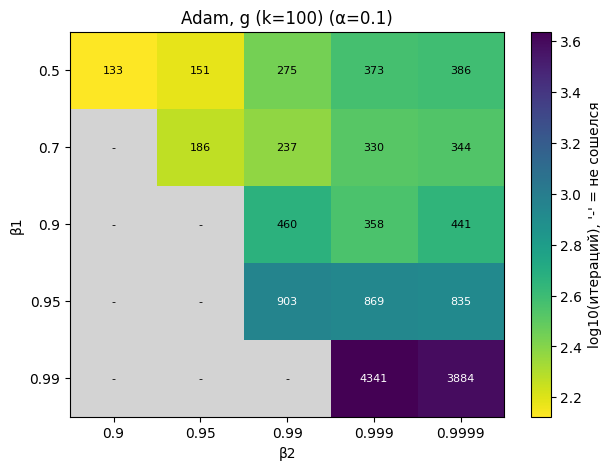

In [6]:
study_quadratic("g", "g (k=100)", grad_quad_bad, (5., 5.))

## Пункт 2

Траектории методов на квадратичных функциях (по одному набору параметров на метод). Зеленая точка - старт, красная звезда - минимум.

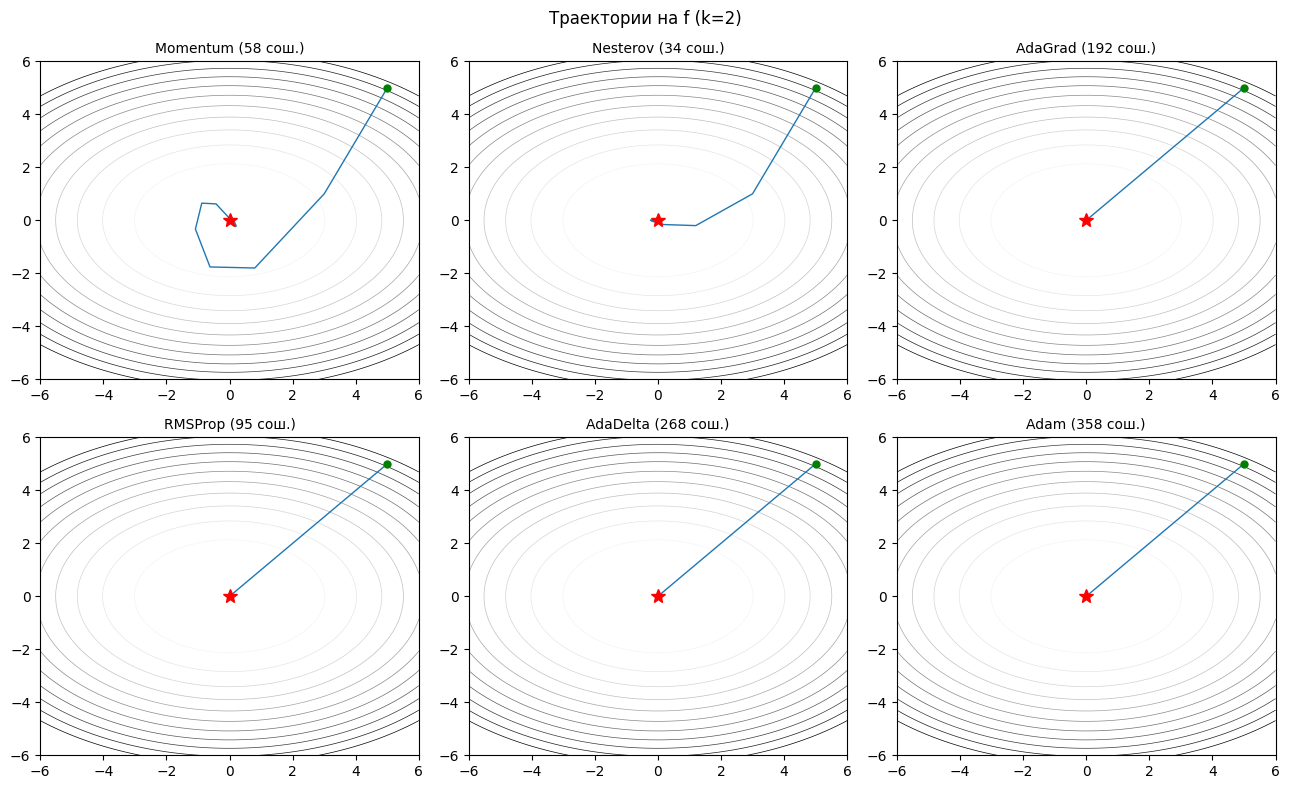

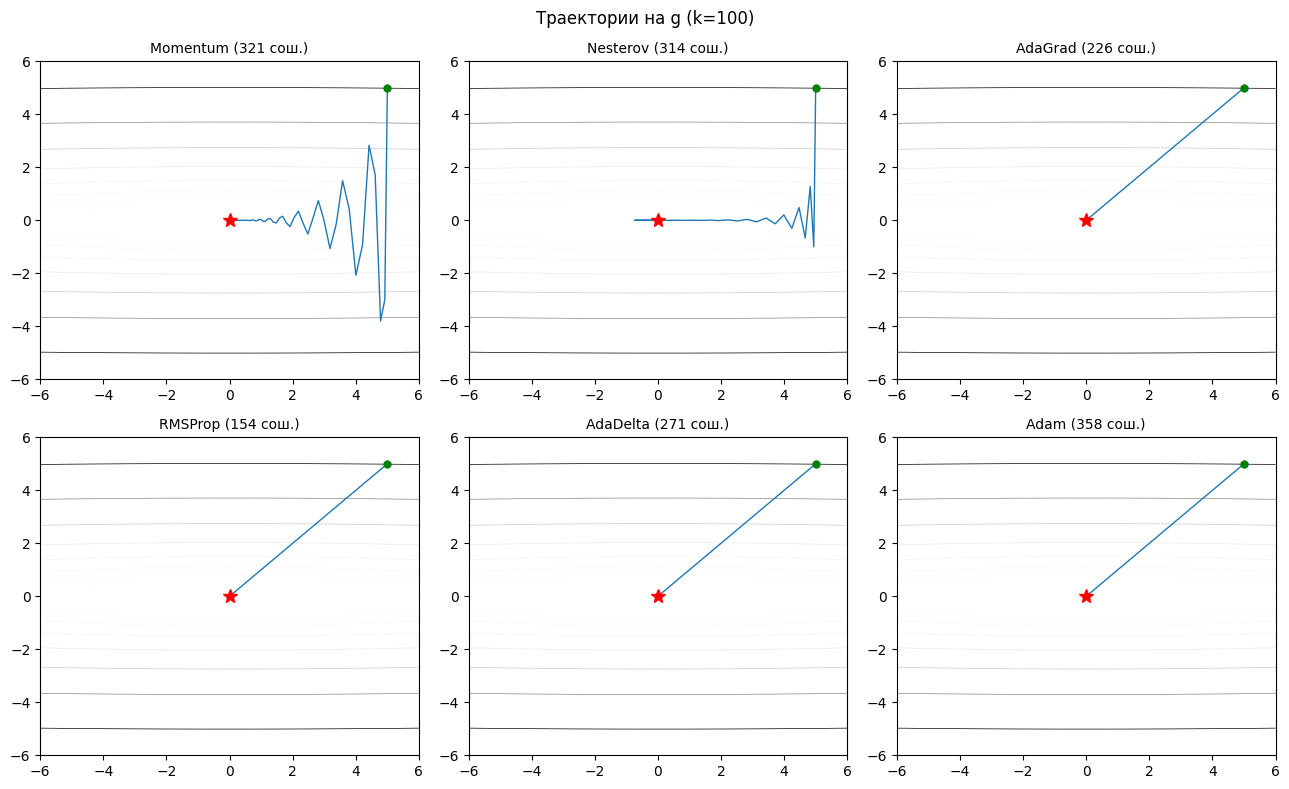

In [7]:
for key, name, f, grad, x0 in [
    ("f", "f (k=2)", f_quad_good, grad_quad_good, (5., 5.)),
    ("g", "g (k=100)", g_quad_bad, grad_quad_bad, (5., 5.))]:
    runs = []
    for mname in METHODS:
        r = run(mname, grad, x0, **CHOSEN[key][mname])
        tag = "сош." if r["converged"] else "X"
        runs.append((f"{mname} ({r['iters']} {tag})", r["traj"]))
    traj_figure(f"Траектории на {name}", f, key, runs)

## Пункт 3

Сложные функции. Сначала для каждого метода 2-3 набора параметров и число итераций на каждой функции, затем по одному набору и по 2 старта - траектории.

In [ ]:
funcs = [("rosen", "Розенброка", rosenbrock, grad_rosenbrock, (-1.2, 1.0)),
         ("ackley", "Экли", ackley, grad_ackley, (2.0, 2.0)),
         ("himmel", "Химмельблау", himmelblau, grad_himmelblau, (0.0, 0.0))]
for key, name, f, grad, x0 in funcs:
    rows = []
    for mname in METHODS:
        for label, params in COMPLEX_SETS[mname]:
            r = run(mname, grad, x0, **params)
            rows.append([mname, label, r["iters"], "да" if r["converged"] else "нет"])
    print_table(f"Функция {name}, старт {x0}: число итераций",
                ["Метод", "параметры", "итераций", "сошелся"], rows)


Функция Розенброка, старт (-1.2, 1.0): число итераций
метод    | параметры      | итераций | сошелся
---------+----------------+----------+--------
Momentum | α=0.001,β=0.9  | 4128     | да     
Momentum | α=0.0005,β=0.9 | 8504     | да     
Momentum | α=0.001,β=0.5  | 21772    | да     
Nesterov | α=0.001,β=0.9  | 4179     | да     
Nesterov | α=0.0005,β=0.9 | 8555     | да     
Nesterov | α=0.001,β=0.5  | 21781    | да     
AdaGrad  | α=0.1          | 50000    | нет    
AdaGrad  | α=0.5          | 22452    | да     
AdaGrad  | α=1.0          | 43243    | да     
RMSProp  | α=0.001,ρ=0.9  | 50000    | нет    
RMSProp  | α=0.01,ρ=0.9   | 50000    | нет    
RMSProp  | α=0.01,ρ=0.99  | 50000    | нет    
AdaDelta | ρ=0.9          | 50000    | нет    
AdaDelta | ρ=0.95         | 23674    | нет    
AdaDelta | ρ=0.99         | 50000    | нет    
Adam     | α=0.01         | 5975     | да     
Adam     | α=0.05         | 2821     | да     
Adam     | α=0.1          | 1987     | да     

Функ

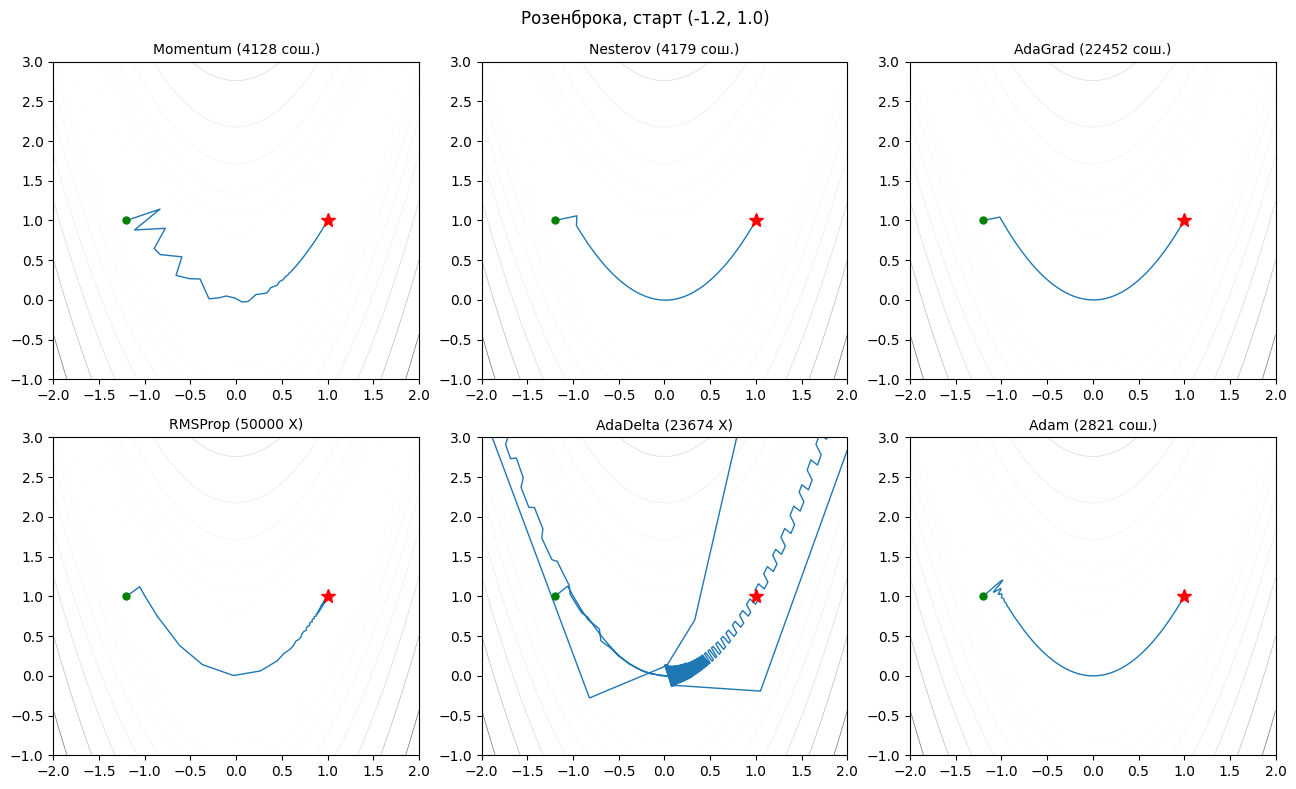

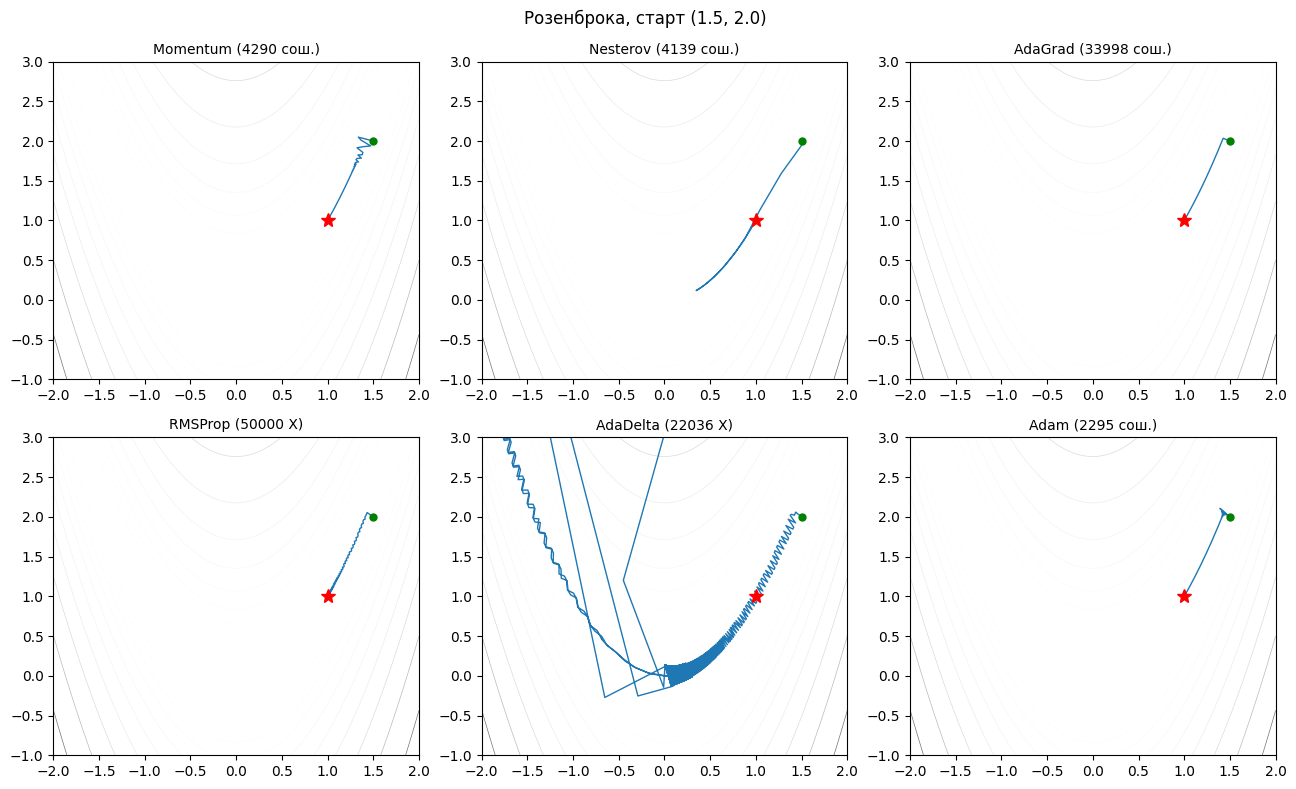

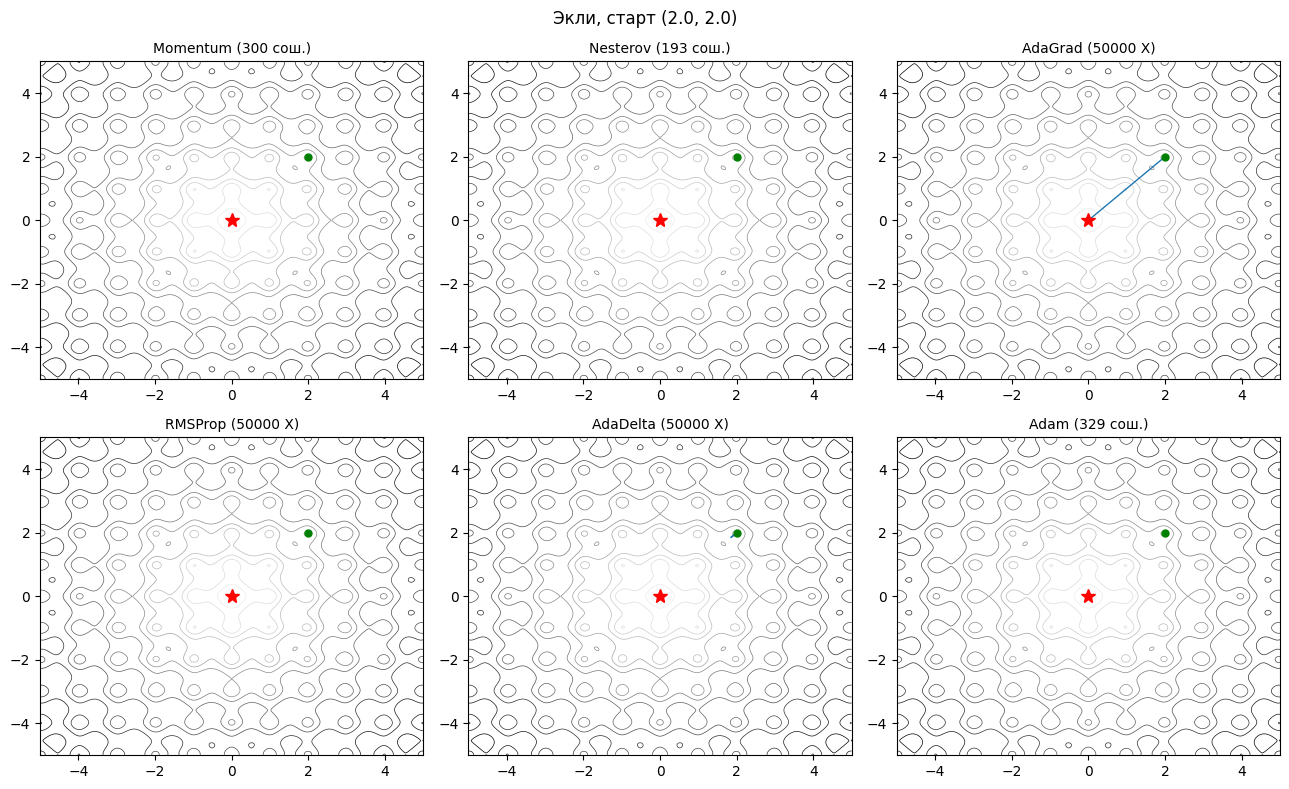

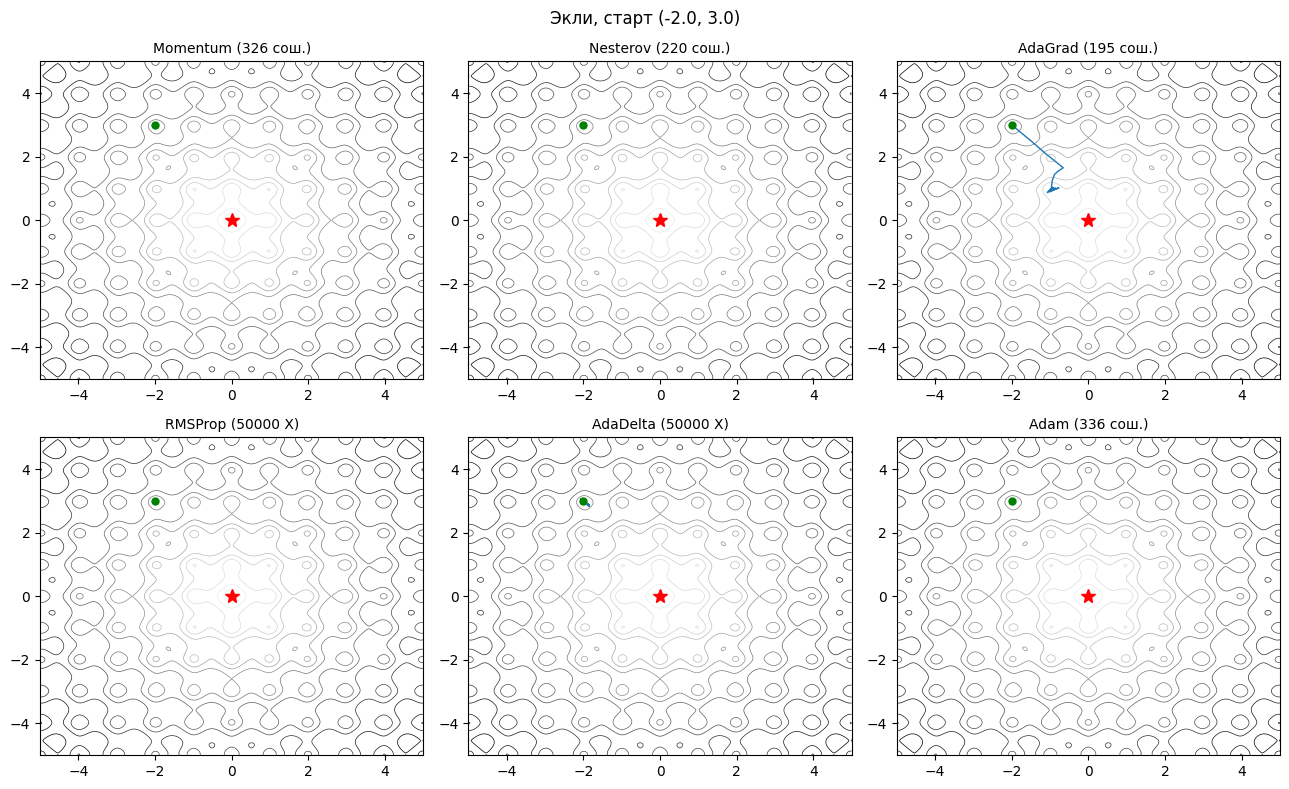

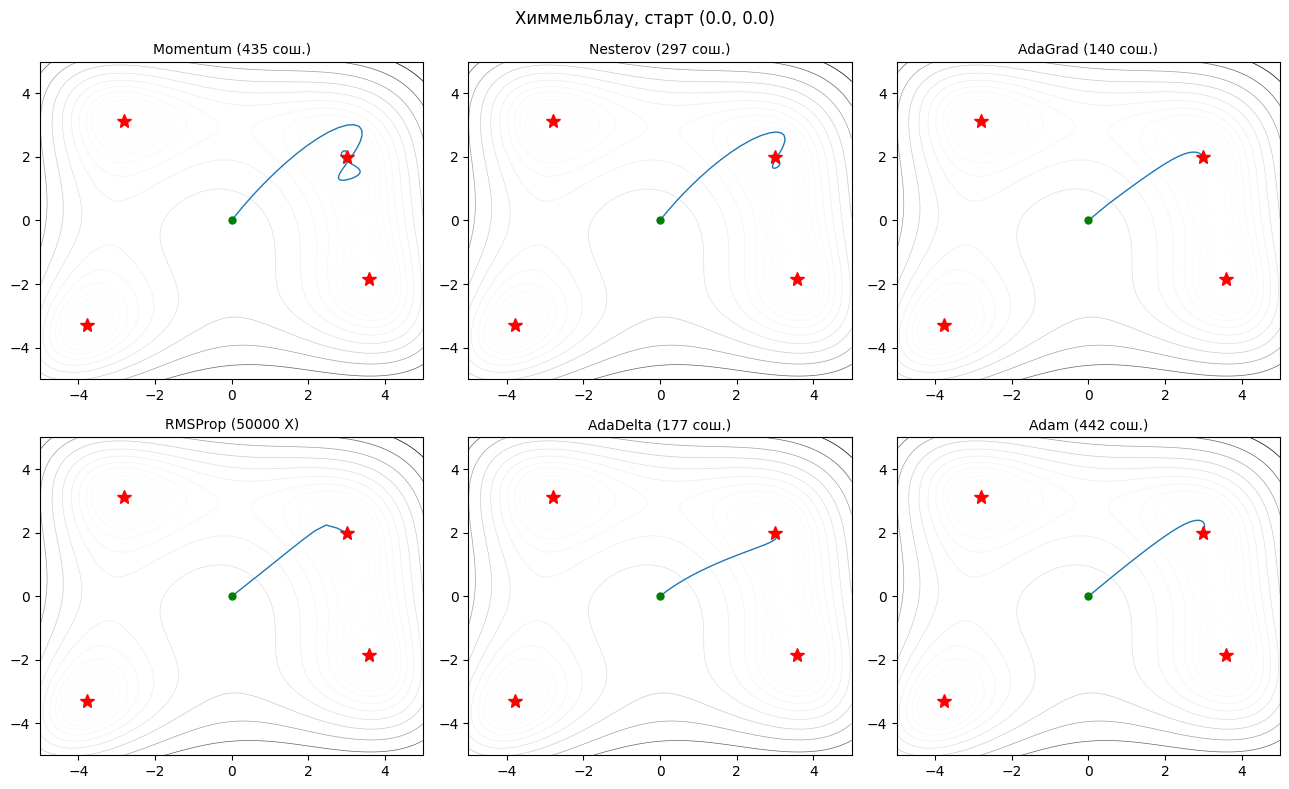

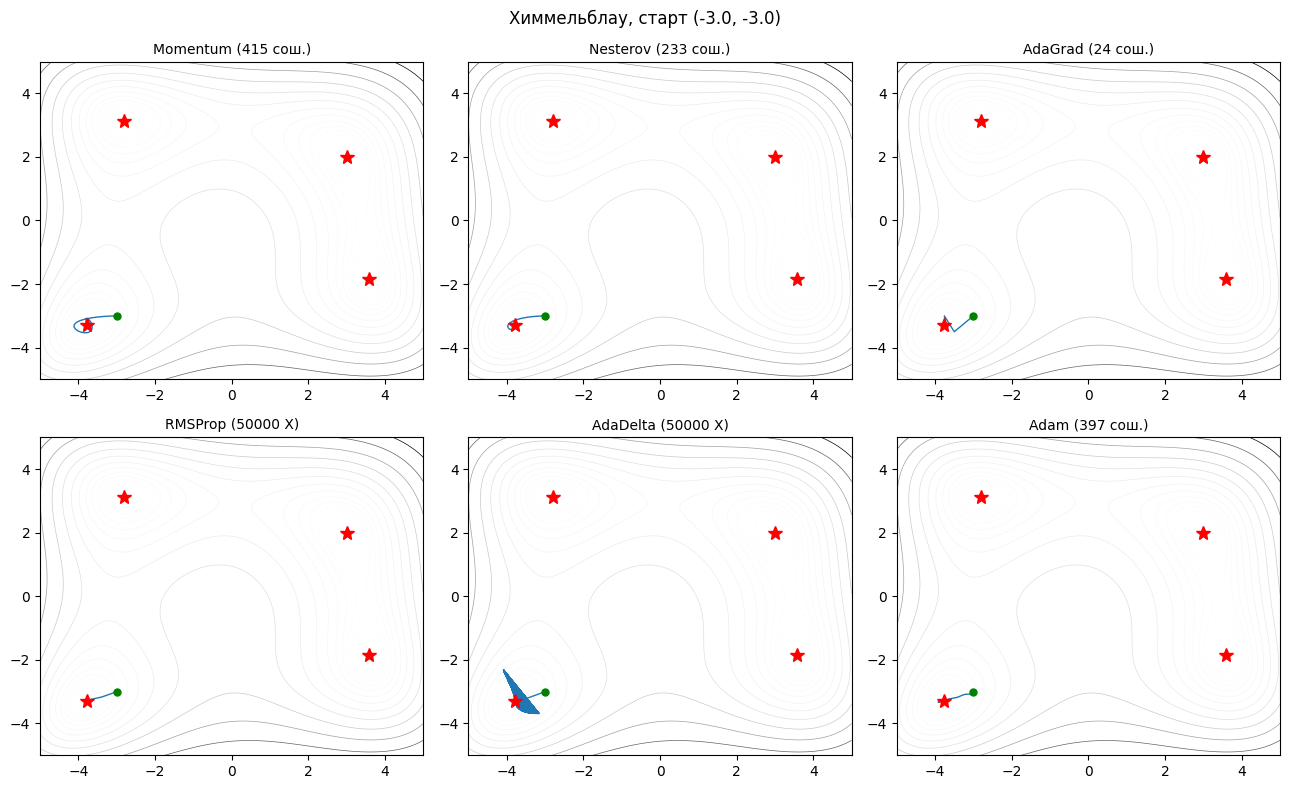

In [9]:
for key, name, f, grad, _ in funcs:
    for x0 in STARTS[key]:
        runs = []
        for mname in METHODS:
            r = run(mname, grad, x0, **COMPLEX_CHOSEN[mname])
            tag = "сош." if r["converged"] else "X"
            runs.append((f"{mname} ({r['iters']} {tag})", r["traj"]))
        traj_figure(f"{name}, старт {x0}", f, key, runs)

## Выводы

1. **Momentum** сильно ускоряет плохо обусловленную функцию `g` (с β=0.9 ~430 итераций против ~1100-5000 без инерции), но на хорошо обусловленной `f` инерция скорее мешает - при больших β возникают колебания и метод замедляется. Слишком большие α и β приводят к расходимости.
2. **Nesterov** ведет себя как momentum, но за счет "заглядывания вперед" лучше гасит колебания: на `g` при β=0.9 он сходится быстрее momentum (~314 против ~430). При этом сочетание большого шага и большой инерции у него тоже может расходиться.
3. **AdaGrad** сильно зависит от начального шага: при малом α (0.1) метод почти останавливается (тысячи итераций, накопленный `G` гасит шаг), при большом α - быстро. Это прямое следствие того, что `G` только растет.
4. **RMSProp** требует, чтобы ρ не было слишком малым (при ρ=0.5 метод расходится). С удачными α и ρ он один из самых быстрых на квадратиках, но на сложных функциях (Розенброк, Экли) часто не достигает 1e-8 - колеблется около минимума.
5. **AdaDelta** не имеет явного шага; лучший результат при ρ≈0.9, при малом ρ расходится. На квадратиках работает, на Розенброке/Экли так же, как RMSProp, не дотягивает до 1e-8.
6. **Adam** = momentum + RMSProp: есть "треугольная" область устойчивости (большой β1 требует большого β2). На сложных функциях Adam самый универсальный - единственный, кто уверенно сходится на Розенброке (≈2000 итераций), и стабильно работает на Экли и Химмельблау.
7. **Геометрия траекторий**: на плохо обусловленной `g` методы с инерцией (Momentum/Nesterov) колеблются вдоль оврага, а адаптивные методы (AdaGrad/RMSProp/AdaDelta/Adam) идут почти по прямой к минимуму, потому что масштабируют шаг по каждой координате отдельно и тем самым "выпрямляют" вытянутый овраг.